---
title: Multi-feature inference
---

In [1]:
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior, 
    ExpStepSize, ExpRegularization, clear_caches,
    Adam, Adagrad, RMSprop, SGDMomentum, 
    SparseObservations, dense_to_sparse, is_sparse_observations,
) # ALWAYS import phasic first to set jax backend correctly
import numpy as np
import jax.numpy as jnp
import pandas as pd
from typing import Optional
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
from tqdm.auto import tqdm
from vscodenb import set_vscode_theme

np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')

## Rewards

We can fit to reward transformed observations, like the total branch length of the coalescent. In the example below, we sample total branch lengths from the model and pass them to `svgd` along with the appropriate rewards.

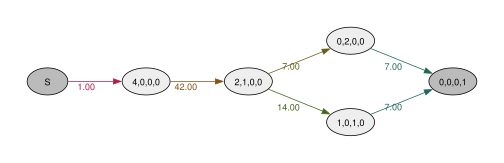

In [2]:
nr_samples = 4

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):            
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue 
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

true_theta = [7]
graph = Graph(coalescent_1param) # should check using the graph hash if a trace of the graph is cached or available online
graph.update_weights(true_theta)
graph.plot()

In [3]:
rewards = graph.states().T
rewards = np.sum(rewards, axis=0)
nr_observations = 10000
observed_data = graph.sample(nr_observations, rewards=rewards)
observed_data

array([0.72472127, 0.23189897, 0.76690399, ..., 0.14690409, 0.1503989 ,
       1.84059088], shape=(10000,))

In [4]:
prior = GaussPrior(ci=[5, 25])
step_size = ExpStepSize(first_step=0.05, last_step=0.01, tau=30.0)

In [5]:
#graph.compute_trace()
svgd = graph.svgd(observed_data=observed_data, 
                  rewards=rewards,
                  prior=prior,
                #   learning_rate=step_size
                learning_rate=ExpStepSize(first_step=0.05, last_step=0.01, tau=30.0)
                    # optimizer=Adam(0.3),
                  )

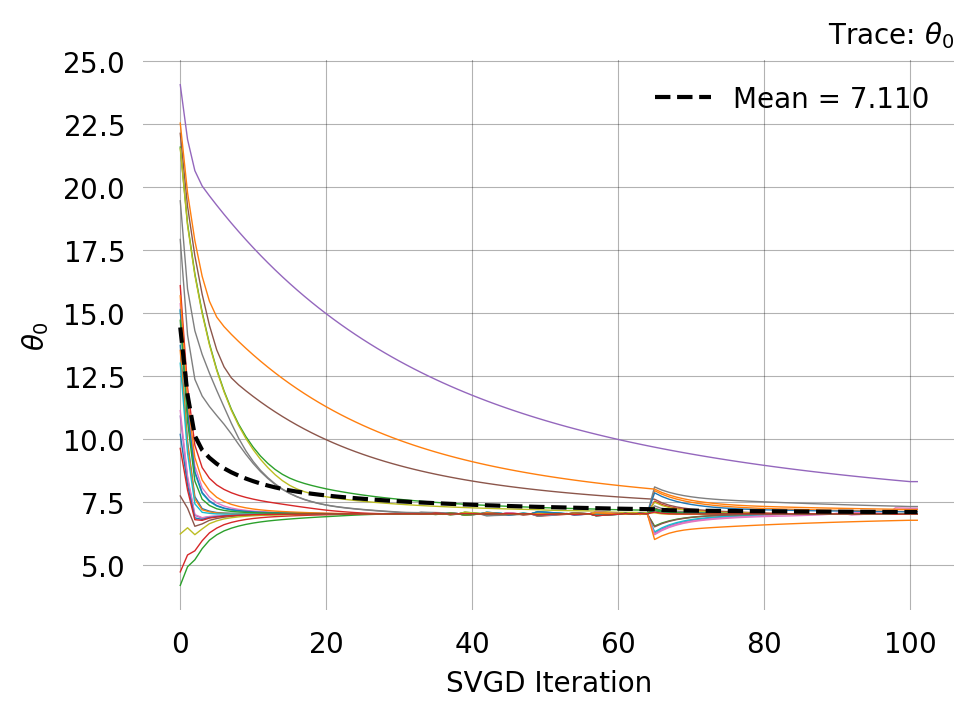

In [6]:
svgd.plot_trace() ;

In [7]:
svgd.summary()

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         7.0307     7.1100     0.2699     6.7813       7.3265      

Particles: 24, Iterations: 100


In [8]:
svgd.get_results()["theta_mean"].item()

7.109994623615635

In [9]:
svgd.map_estimate_from_particles()

([7.030690326868407], -1465.875491525652)

## Multi-feature observations

Observations can be vectors of features, in which case you need to supply a set or rewards for each feature. The example below is the the same as above, except that we pass observations as single-value vectors.

In [10]:
# same as above
graph = Graph(coalescent_1param)
graph.update_weights(true_theta)

nr_observations = 10000

rewards = graph.states().T
rewards = np.sum(rewards, axis=0)
observed_data = graph.sample(nr_observations, rewards=rewards)

In [11]:

# make reward vector the only row of a 2d array
rewards = np.reshape(rewards, (-1, len(rewards))) 
# reshape data into a single-column 2d array
observed_data = np.reshape(observed_data, (len(observed_data), -1)) 

In [12]:

# #graph.compute_trace()
# svgd = graph.svgd(observed_data=observed_data, rewards=rewards, **params)
# svgd.get_results()["theta_mean"].item()

In [14]:
# svgd.map_estimate_from_particles()

With more than one feature, SVGD computes the likelihood for each feature using the the provided rewards. In this example, sample 1'ton, 2'ton, and 3'ton branch lengths are first, second and third observation features. The reward matrix passed to `svgd` must have as many rows as your data has features. Three rows in the reward matrix:

In [13]:
graph = Graph(coalescent_1param)
graph.update_weights(true_theta)

rewards = graph.states().T
rewards = rewards[:-1]
rewards

array([[0, 4, 2, 0, 1, 0],
       [0, 0, 1, 2, 0, 0],
       [0, 0, 0, 0, 1, 0]], dtype=int32)


Data must be passed to `svgd` as a `SparseData` object. You can create it like this:


In [14]:
n = nr_observations
idxs = np.arange(rewards.shape[0])
feature_data = np.concatenate([graph.sample(n, rewards=rewards[i]) for i in idxs])
features = np.concatenate([[i]*n for i in idxs])
feature_slices = [(i*n, (i+1)*n) for i in idxs]

sparse_observations = SparseObservations(
    values=observed_data,
    features=features,
    n_features=3, 
    slices=feature_slices
)
sparse_observations

SparseObservations(values=<10000 values>, n_features=<3, features=<10000 values>, slices=<10000 values>)

It can also be created from a two-dimensional array where each row is an observation with all but a single non-nan value:

In [15]:
n = nr_observations
observed_data = np.zeros((n * (rewards.shape[0]), rewards.shape[0]), dtype=float)
observed_data[:] = np.nan
for i in range(rewards.shape[0]):
    observed_data[(i*n):((i+1)*n), i] = graph.sample(n, rewards=rewards[i])
np.random.shuffle(observed_data)
observed_data[:nr_observations] # just the first nr_observations rows
observed_data

array([[0.2151755 ,        nan,        nan],
       [       nan,        nan, 0.        ],
       [       nan,        nan, 0.12203013],
       ...,
       [0.94441191,        nan,        nan],
       [0.16039439,        nan,        nan],
       [       nan, 0.00995706,        nan]], shape=(30000, 3))

In [16]:
sparse_observations = dense_to_sparse(observed_data)
sparse_observations

SparseObservations(values=<30000 values>, n_features=<3, features=<30000 values>, slices=<30000 values>)

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         7.6701     8.7813     2.8778     4.9918       12.1572     

Particles: 24, Iterations: 200


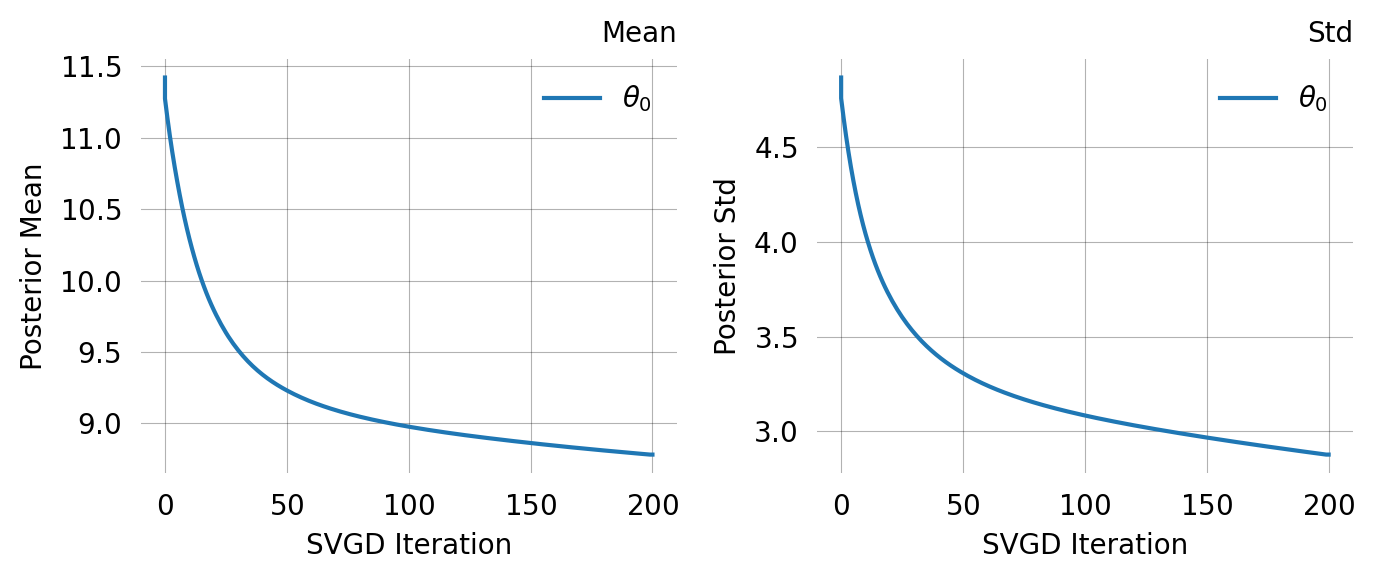

In [17]:
graph = Graph(coalescent_1param)

svgd = graph.svgd(observed_data=sparse_observations, 
                  rewards=rewards, 
                  prior=GaussPrior(ci=[1, 20]),  
                  n_iterations=200,                
            learning_rate=ExpStepSize(first_step=0.01, last_step=0.001, tau=30.0)
                  )
svgd.summary()
svgd.plot_convergence() ;

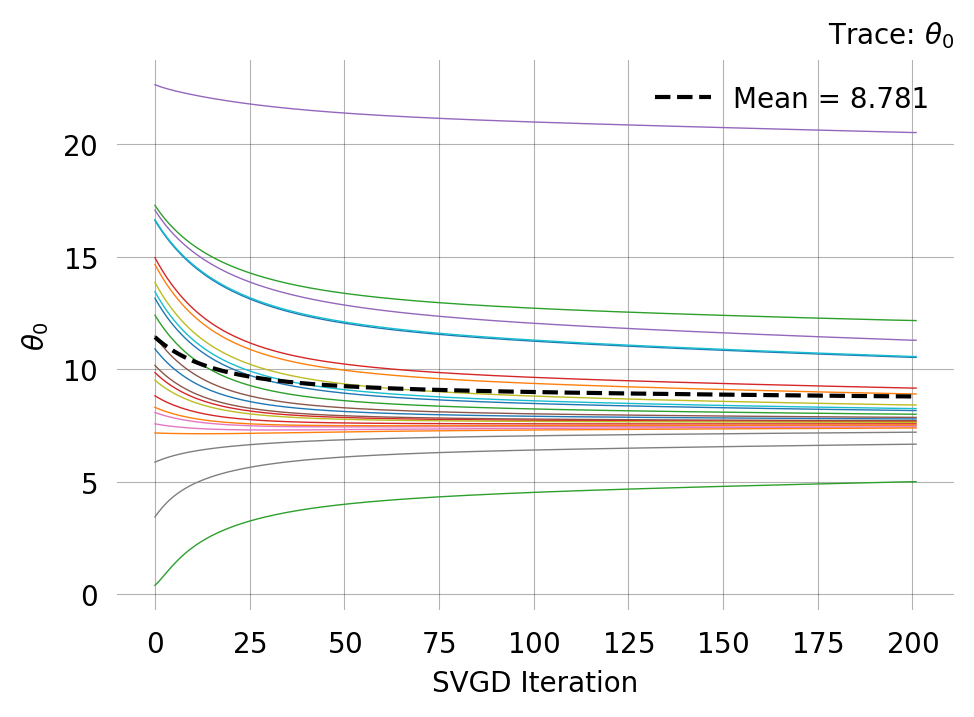

In [18]:
svgd.plot_trace()